<font color=#009afa size=50>DAT5001 - Visualisation of Data</font>

<font size=50>2 - Creating Graphs and Charts for Presentation</font>

|**Assessment Code:** |PRES1|
|---|---|
|**Author:**|Tom Rowan, ST20285213|
|**Course:**| DAT5001_S2_25|
|**Course Tutor:**|Dr. Imtiaz Khan|


## Initialise Notebook

In [ ]:
# Install Requirements Using Pip
# %pip install -r requirements.txt

%pip install requests pandas numpy matplotlib seaborn plotly cartopy geopandas geopy pycountry scikit-learn lifelines networkX holoviews IPython
 

### Import Python Libraries

In [48]:
# Standard Libraries
import json
import random
from datetime import datetime
import sys

# Pandas and numpy
import pandas as pd
import numpy as np

# Matplot Lib
import matplotlib.pyplot as plt
from matplotlib import colormaps
import matplotlib.colors as mcolors
from matplotlib.pyplot import figure
import matplotlib.ticker as mticker
%matplotlib inline

# Seaborn Graphs
import seaborn as sns

# Cartopy Maps
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# Geopandas
import geopandas as gpd

# GeoPy
from geopy.geocoders import Nominatim
from geopy.extra.rate_limiter import RateLimiter

# Pycountry 
import pycountry

# Tabulate
from tabulate import tabulate

# Colorama
from colorama import Fore, Back, Style

# Requests
import requests

# Plotly
import plotly.express as px
import plotly.graph_objects as go

# Do not print warnings!
import warnings
warnings.filterwarnings('ignore')

### Check for Internet Access

In [49]:
# Function to print coloured output
def print_output (str1, str2, delim=':', colour='yellow'):
    if colour.upper() in dir(Fore):
        colour = colour.upper()
    else:
        colour = 'YELLOW'
    print (f'{getattr(Fore, colour)}{str(str1)}{delim}{Style.RESET_ALL} {str(str2)}')

In [50]:
online = False

# Check for Internet Connectivity
def check_internet (url_list):
    online = False
    for _url in url_list:
        try:
            response = requests.get(_url, timeout=3)
            if response.status_code == 200:
                online = True
                break
        except requests.RequestException:
            output_string = f"Check Internet failed for {_url}"
            print_output ('[FAIL]',output_string, colour='red', delim='')
    return online


_urls_to_check = ['http://connectivitycheck.gstatic.com/generate_204',
                  'https://www.planet4589.org',
                  'https://datascience.daemonchild.com']

if check_internet (_urls_to_check ):
    print_output ('[INTERNET]','Internet Connectivity Detected. Using Internet resources.',colour='green', delim='')
    online = True

else:
    print ()
    print_output ('[INTERNET]','No Internet Connectivity.', colour='red', delim='')
    #sys.exit('Stopping notebook running here.')


[INTERNET] Internet Connectivity Detected. Using Internet resources.


### Load latest version of Cleaned Dataset

In [51]:
if online:
    #sdf = pd.read_csv('https://datascience.daemonchild.com/year2/dat5001/pres1/datasets/cleaned_engineered_sdf.csv')
    sdf = pd.read_csv('../../datasets/space_objects_latest.csv')
else:
    sdf = pd.read_csv('../../datasets/space_objects_latest.csv')

In [52]:
sdf.shape

(66691, 54)

In [53]:
sdf.columns

Index(['Apogee', 'Class', 'CosparID', 'Country', 'Country Code', 'Decay Date',
       'Decay Decade', 'Decay Month', 'Decay Month No', 'Decay Year',
       'Diameter', 'In Orbit', 'Launch Date', 'Launch Decade', 'Launch Month',
       'Launch Month No', 'Launch Year', 'Length', 'Lifespan Days',
       'Lifespan Months', 'Lifespan Years', 'Manufacturer City',
       'Manufacturer Code', 'Manufacturer Country',
       'Manufacturer Country Code', 'Manufacturer GeoInfo',
       'Manufacturer Latitude', 'Manufacturer Long Name',
       'Manufacturer Longitude', 'Manufacturer Parent',
       'Manufacturer Short Name', 'Manufacturer State', 'Mass', 'Name',
       'Operator City', 'Operator Code', 'Operator Country',
       'Operator Country Code', 'Operator GeoInfo', 'Operator Latitude',
       'Operator Long Name', 'Operator Longitude', 'Operator Parent',
       'Operator Short Name', 'Operator State', 'Perigee', 'Primary Category',
       'Program', 'Program Root', 'Secondary Category', 'S

## Define Palette

These graphs will end up in the PowerPoint presentation. This is the colour palette.

In [54]:

graph_palette = {
  "foreground": {
    "gold": "#FFBD02",
    "steelBlue": "#4977AA",
    "burntOrange": "#D94F00",
    "skyBlue": "#7EC8E3",
    "slateGrey": "#3E4A58",
    "green": "#087616",
    "lightGrey":"#A9A9A9"   
  },
  "background": {
    "darkBlue": "#0F1A37",
    "navyBlue": "#192B4D",
    "midnightBlue": "#121F36",
    "charcoal": "#1E2A3A"
  }
}
   

Create a graduated scale for maps and/or heatmaps

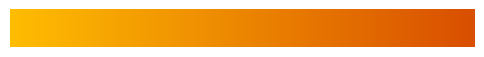

In [55]:

# Create a linear colormap
cmap_gold_orange = mcolors.LinearSegmentedColormap.from_list("GoldToSteelBlue", [graph_palette['foreground']['gold'], graph_palette['foreground']['burntOrange']])

# --- Example: visualize the gradient ---
fig, ax = plt.subplots(figsize=(6, 1))
fig.subplots_adjust(bottom=0.5)

# Create gradient data
gradient = np.linspace(0, 1, 256).reshape(1, -1)

ax.imshow(gradient, aspect="auto", cmap=cmap_gold_orange )
ax.set_axis_off()
plt.show()


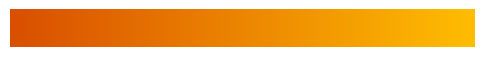

In [56]:

# Create a linear colormap
cmap_orange_gold = mcolors.LinearSegmentedColormap.from_list("BurntOrangetoGold", [graph_palette['foreground']['burntOrange'], graph_palette['foreground']['gold']])

# --- Example: visualize the gradient ---
fig, ax = plt.subplots(figsize=(6, 1))
fig.subplots_adjust(bottom=0.5)

# Create gradient data
gradient = np.linspace(0, 1, 256).reshape(1, -1)

ax.imshow(gradient, aspect="auto", cmap=cmap_orange_gold)
ax.set_axis_off()
plt.show()

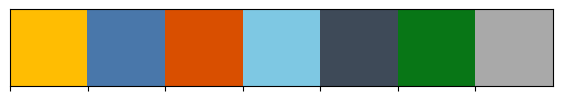

In [57]:
# Background
bg = graph_palette['background']['darkBlue']

# Extract foreground colours
foreground_colours = list(graph_palette["foreground"].values())
background_colours = list(graph_palette["background"].values())

# Create a Seaborn palette
sns_palette = sns.color_palette(foreground_colours)

# Optional: Set as default palette
sns.set_palette(sns_palette)

# Preview the palette
sns.palplot(sns_palette)
plt.show()

## Graphs for Presentation

Need to create:

- Objects added by year, showing remaining in orbit
- Pie chart: Breakdown of objects by category (satellites, rocket bodies, debris).
- Bar chart: Payload categories (military, comms, scientific, etc.).
- Bar chart or map: Top countries or organisations responsible for objects in orbit.
- Histogram: Time between launch and re-entry for satellites.
- Visual: Timeline or scatter plot of known collisions or near misses. ... where do we get this data?


Create some filtered datasets

In [58]:
# Filter dataframe for satellites still in orbit
sdf_in_orbit = sdf[sdf['In Orbit'] == True]

# Filter for Type == 'P'
sdf_payloads_in_orbit = sdf_in_orbit[sdf_in_orbit['Type'] == 'Payload']

# Ensure dates are parsed
sdf['Launch Date'] = pd.to_datetime(sdf['Launch Date'], errors='coerce')

# Filter for objects still in orbit
in_orbit_df = sdf[sdf['In Orbit'] == True].dropna(subset=['Launch Date'])

# Group by year for cumulative count
cumulative_by_year = in_orbit_df.groupby(in_orbit_df['Launch Date'].dt.year).size().cumsum()

# Group by year for launches (all objects)
launches_by_year = sdf.dropna(subset=['Launch Date']).groupby(sdf['Launch Date'].dt.year).size()


## Apogee and Perigee

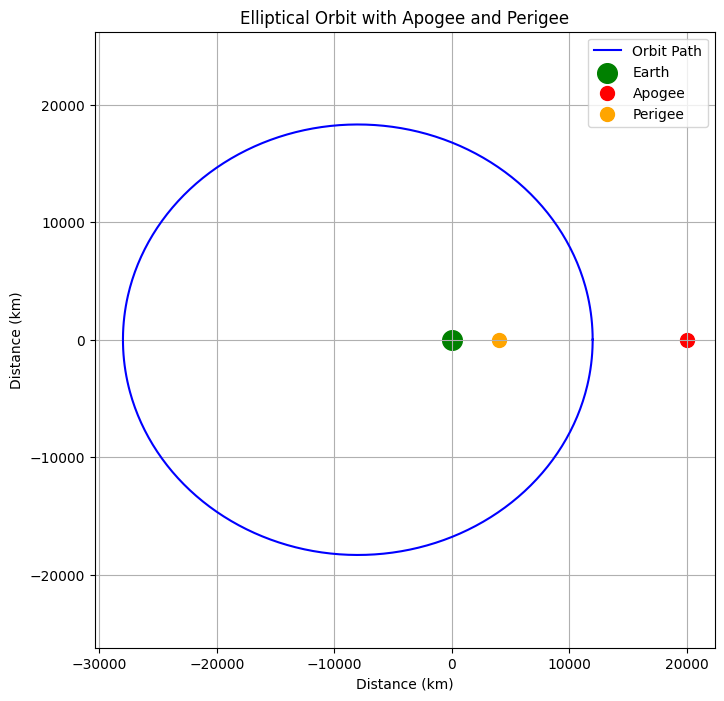

In [59]:
import matplotlib.pyplot as plt
import numpy as np

# Example orbital parameters (semi-major axis and eccentricity)
semi_major_axis = 20000   # km
eccentricity = 0.4        # 0 = circle, closer to 1 = very stretched

# Calculate semi-minor axis
semi_minor_axis = semi_major_axis * np.sqrt(1 - eccentricity**2)

# Parametric equation for ellipse
theta = np.linspace(0, 2*np.pi, 500)
x = semi_major_axis * np.cos(theta) - semi_major_axis * eccentricity  # shift Earth to one focus
y = semi_minor_axis * np.sin(theta)

# Apogee (farthest point) and Perigee (closest point)
apogee_x = semi_major_axis * (1 + eccentricity) - semi_major_axis * eccentricity
apogee_y = 0
perigee_x = semi_major_axis * (1 - eccentricity) - semi_major_axis * eccentricity
perigee_y = 0

# Plot
plt.figure(figsize=(8,8))
plt.plot(x, y, label='Orbit Path', color='blue')
plt.scatter(0, 0, color='green', s=200, label='Earth')  # Earth at focus
plt.scatter(apogee_x, apogee_y, color='red', s=100, label='Apogee')
plt.scatter(perigee_x, perigee_y, color='orange', s=100, label='Perigee')

# Labels and styling
plt.title('Elliptical Orbit with Apogee and Perigee')
plt.xlabel('Distance (km)')
plt.ylabel('Distance (km)')
plt.legend()
plt.axis('equal')
plt.grid(True)
plt.show()


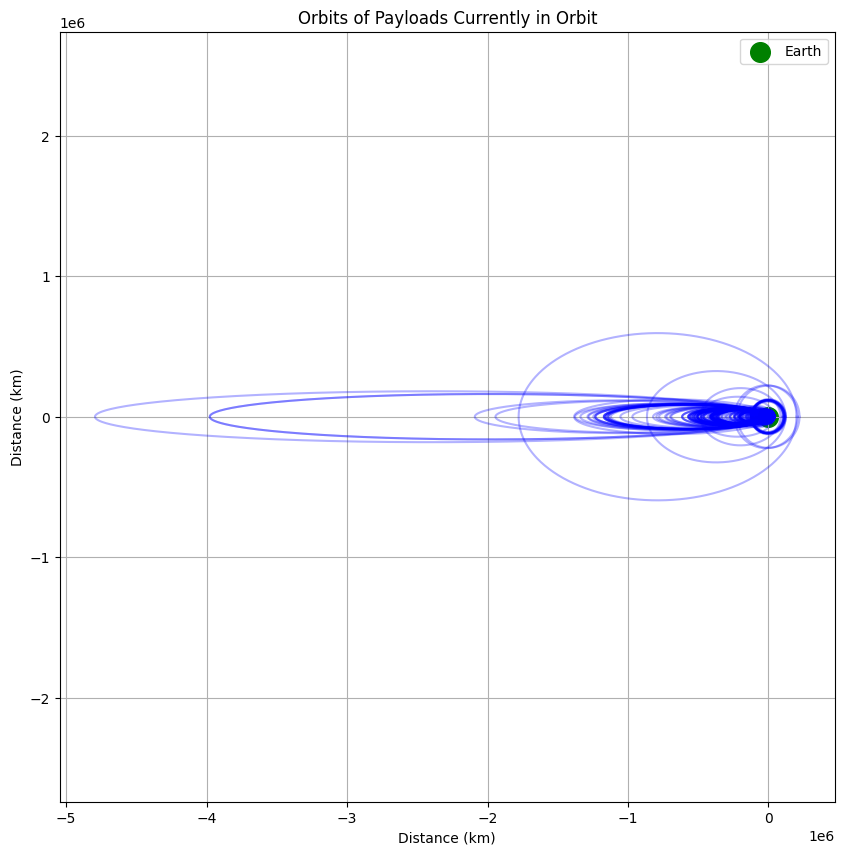

In [60]:
# sdf_payloads_in_orbit <-- use this

# Filter dataframe for payloads still in orbit
payloads = sdf[(sdf['Type'] == 'Payload') & (sdf['In Orbit'] == True)].copy()

# Ensure numeric values
payloads['Apogee'] = pd.to_numeric(payloads['Apogee'], errors='coerce')
payloads['Perigee'] = pd.to_numeric(payloads['Perigee'], errors='coerce')

# Drop rows with missing values
payloads = payloads.dropna(subset=['Apogee', 'Perigee'])

# Plot setup
plt.figure(figsize=(10,10))

# Loop through each payload and plot its orbit
theta = np.linspace(0, 2*np.pi, 500)
earth_radius = 6371  # km

for _, row in payloads.iterrows():
    apogee = row['Apogee'] + earth_radius
    perigee = row['Perigee'] + earth_radius
    
    # Skip invalid values
    if apogee <= 0 or perigee <= 0:
        continue
    
    # Semi-major axis and eccentricity
    a = (apogee + perigee) / 2
    e = (apogee - perigee) / (apogee + perigee)
    b = a * np.sqrt(1 - e**2)
    
    # Ellipse coordinates (Earth at one focus)
    x = a * np.cos(theta) - a * e
    y = b * np.sin(theta)
    
    plt.plot(x, y, alpha=0.3, color='blue')

plt.scatter(0, 0, color='green', s=200, label='Earth')  # Earth at focus


plt.title('Orbits of Payloads Currently in Orbit')
plt.xlabel('Distance (km)')
plt.ylabel('Distance (km)')
plt.legend()
plt.axis('equal')
plt.grid(True)
plt.show()


In [61]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Filter dataframe for payloads still in orbit
payloads = sdf[(sdf['Type'] == 'Payload') & (sdf['In Orbit'] == True)].copy()

# Ensure Apogee is numeric
payloads['Apogee'] = pd.to_numeric(payloads['Apogee'], errors='coerce')
payloads = payloads.dropna(subset=['Apogee'])

# Define bins of 50 km
bin_width = 5000
max_apogee = int(payloads['Apogee'].max()) + bin_width
bins = np.arange(0, max_apogee + bin_width, bin_width)

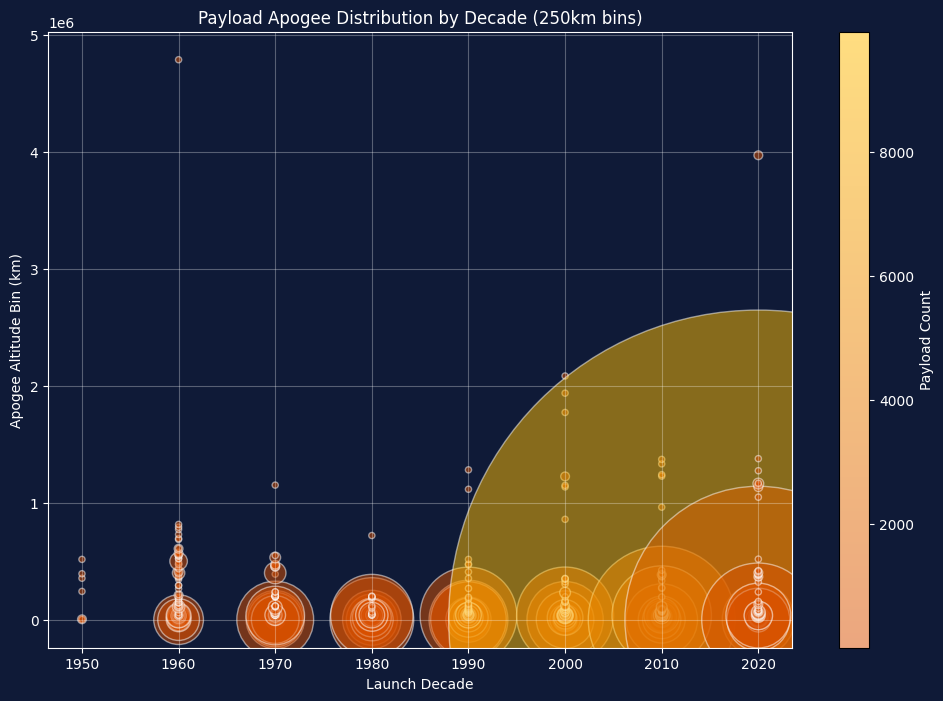

In [62]:

# Filter dataframe for payloads still in orbit
payloads = sdf[(sdf['Type'] == 'Payload') & (sdf['In Orbit'] == True)].copy()

# Ensure numeric values
payloads['Apogee'] = pd.to_numeric(payloads['Apogee'], errors='coerce')
payloads['Launch Decade'] = pd.to_numeric(payloads['Launch Decade'], errors='coerce')
payloads = payloads.dropna(subset=['Apogee','Launch Decade'])

# Remove negative apogees
payloads = payloads[payloads['Apogee'] >= 0]

# Bucket apogee into 500 km ranges
bin_width = 250
payloads['Apogee_bin'] = (payloads['Apogee'] // bin_width) * bin_width

# Group by decade and apogee bin
grouped = payloads.groupby(['Launch Decade','Apogee_bin']).size().reset_index(name='count')

# Plot bubble chart
fig, ax = plt.subplots(figsize=(12,8))
fig.patch.set_facecolor(bg)        # background color
ax.set_facecolor(bg)

scatter = ax.scatter(
    grouped['Launch Decade'],
    grouped['Apogee_bin'],
    s=grouped['count']*20,   # scale bubble size
    c=grouped['count'],
    cmap=cmap_orange_gold,
    alpha=0.5,
    edgecolors='white'
)

# White text and lines
ax.set_title('Payload Apogee Distribution by Decade (' + str(bin_width) + 'km bins)', color='white')
ax.set_xlabel('Launch Decade', color='white')
ax.set_ylabel('Apogee Altitude Bin (km)', color='white')
ax.tick_params(colors='white')
for spine in ax.spines.values():
    spine.set_color('white')

# Colorbar with white text
cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('Payload Count', color='white')
cbar.ax.yaxis.set_tick_params(color='white')
plt.setp(cbar.ax.get_yticklabels(), color='white')

ax.grid(True, color='white', alpha=0.3)
plt.show()  


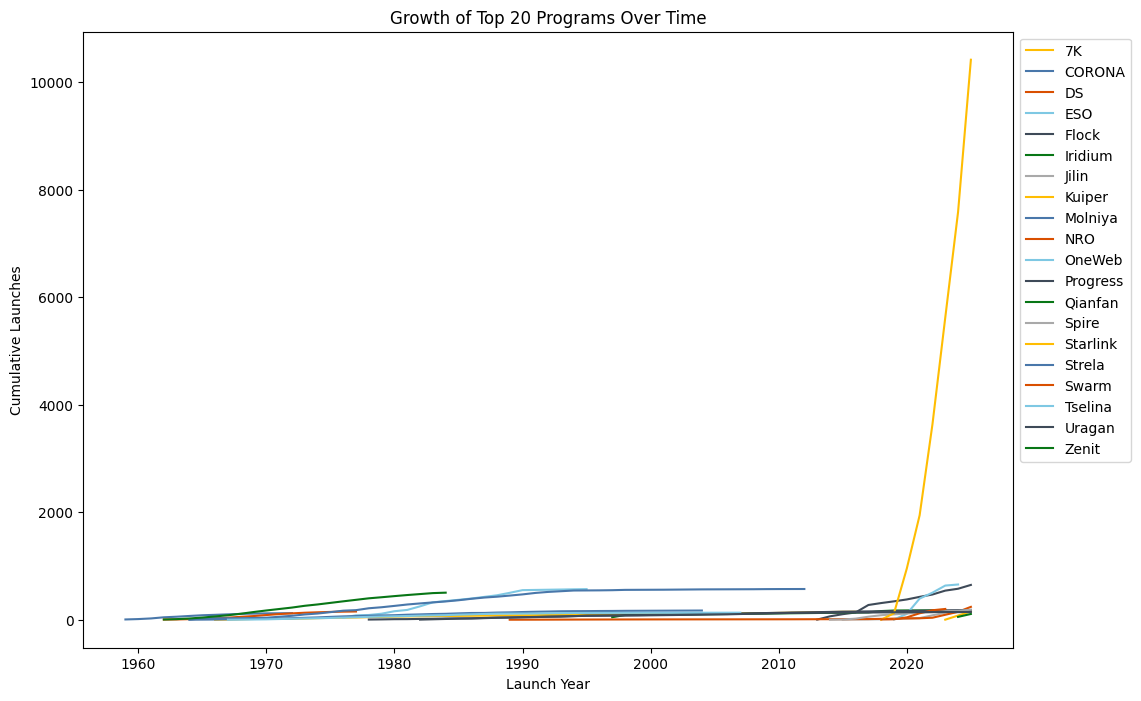

In [63]:
program_counts = (
    sdf.groupby(["Program Root", "Launch Year"])
    .size()
    .reset_index(name="count")
)

top_programs = (
    program_counts.groupby("Program Root")["count"].sum()
    .nlargest(20)
    .index
)

program_counts = program_counts[program_counts["Program Root"].isin(top_programs)]

program_counts = (
    program_counts
    .sort_values(["Program Root", "Launch Year"])
    .groupby("Program Root")
    .apply(lambda df: df.assign(cumulative=df["count"].cumsum()))
    .reset_index(drop=True)
)


import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12,8))

for program, df in program_counts.groupby("Program Root"):
    ax.plot(df["Launch Year"], df["cumulative"], label=program)

ax.set_title("Growth of Top 20 Programs Over Time")
ax.set_xlabel("Launch Year")
ax.set_ylabel("Cumulative Launches")
ax.legend(loc="upper left", bbox_to_anchor=(1,1))  # put legend outside
plt.show()


In [64]:
import plotly.graph_objects as go

# Count launches by Program Root and Launch Decade
program_decade_counts = (
    sdf.groupby(["Program Root", "Launch Decade"])
    .size()
    .reset_index(name="count")
)

# Get top 20 programs overall
top_programs = (
    program_decade_counts.groupby("Program Root")["count"].sum()
    .nlargest(20)
    .index
)

program_decade_counts = program_decade_counts[
    program_decade_counts["Program Root"].isin(top_programs)
]

# Build node labels
programs = list(top_programs)
decades = sorted(program_decade_counts["Launch Decade"].unique())
labels = programs + [f"{d}s" for d in decades]

# Map labels to indices
label_to_index = {label: i for i, label in enumerate(labels)}

# Build Sankey links
sources = []
targets = []
values = []

for _, row in program_decade_counts.iterrows():
    sources.append(label_to_index[row["Program Root"]])
    targets.append(label_to_index[f"{row['Launch Decade']}s"])
    values.append(row["count"])

# Create Sankey diagram
fig = go.Figure(data=[go.Sankey(
    node=dict(
        pad=15,
        thickness=20,
        line=dict(color="black", width=0.5),
        label=labels
    ),
    link=dict(
        source=sources,
        target=targets,
        value=values
    )
)])

fig.update_layout(title_text="Top 20 Programs → Launch Decades", font_size=12)
fig.show()


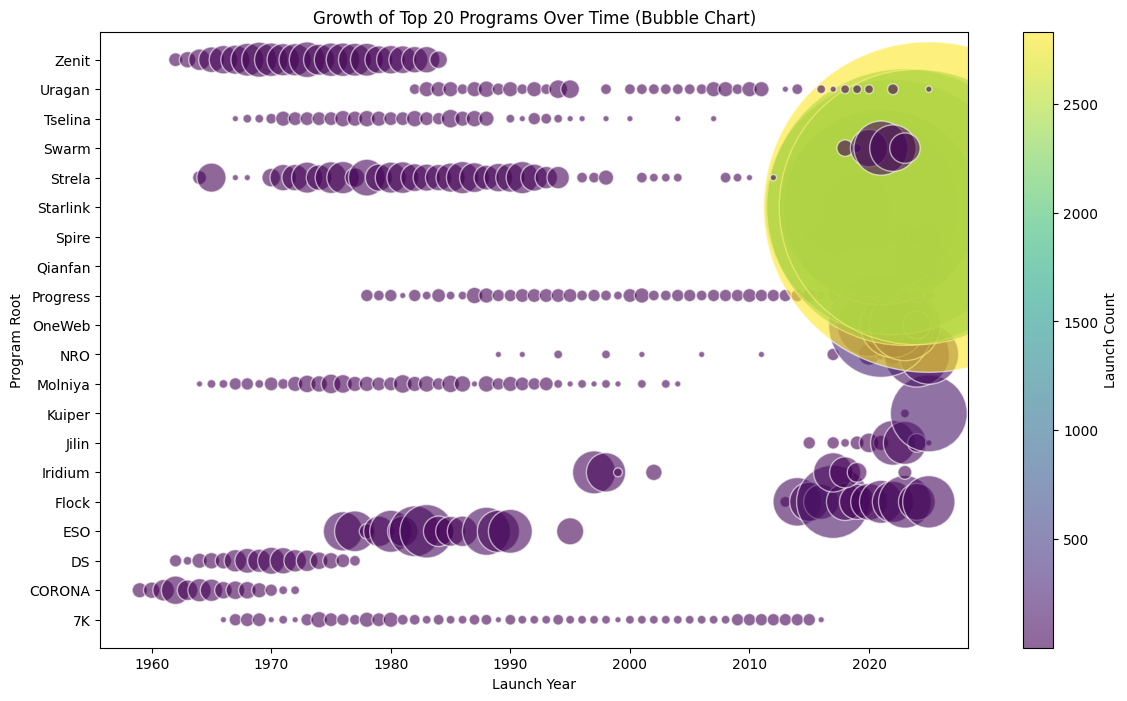

In [65]:
import matplotlib.pyplot as plt

# Count launches per Program Root per year
program_counts = (
    sdf.groupby(["Program Root", "Launch Year"])
    .size()
    .reset_index(name="count")
)

# Get top 20 programs overall
top_programs = (
    program_counts.groupby("Program Root")["count"].sum()
    .nlargest(20)
    .index
)

program_counts = program_counts[program_counts["Program Root"].isin(top_programs)]

# Build bubble chart
fig, ax = plt.subplots(figsize=(14,8))

scatter = ax.scatter(
    program_counts["Launch Year"],
    program_counts["Program Root"],
    s=program_counts["count"]*20,   # bubble size scaled by count
    alpha=0.6,
    c=program_counts["count"],
    cmap="viridis",
    edgecolors="white"
)

ax.set_title("Growth of Top 20 Programs Over Time (Bubble Chart)")
ax.set_xlabel("Launch Year")
ax.set_ylabel("Program Root")

# Add colorbar for counts
cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label("Launch Count")

plt.show()


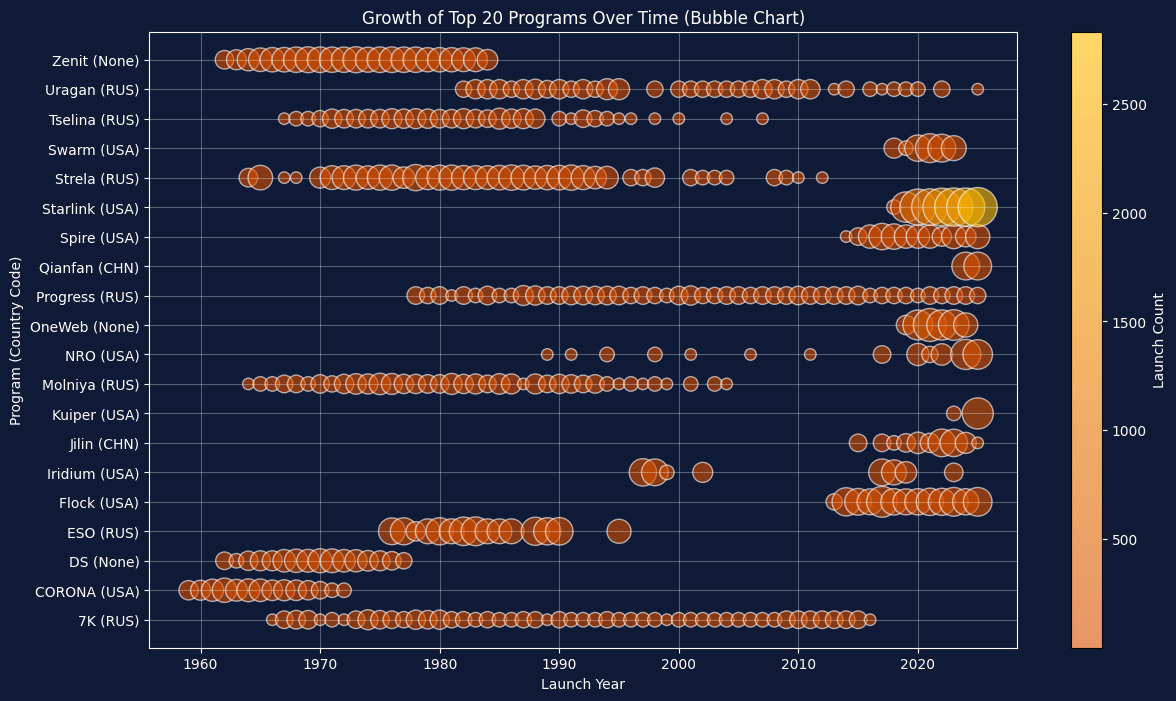

In [66]:
import matplotlib.pyplot as plt

# Count launches per Program Root per year
program_counts = (
    sdf.groupby(["Program Root", "Launch Year"])
    .size()
    .reset_index(name="count")
)

# Get top 20 programs overall
top_programs = (
    program_counts.groupby("Program Root")["count"].sum()
    .nlargest(20)
    .index
)

program_counts = program_counts[program_counts["Program Root"].isin(top_programs)]

# --- Build labels with Program Root + Country Code ---
# Take the first country code seen for each program
program_labels = (
    sdf[sdf["Program Root"].isin(top_programs)]
    .groupby("Program Root")["Country Code"]
    .first()
    .to_dict()
)

# Create new label column
program_counts["Program Label"] = program_counts["Program Root"].map(
    lambda p: f"{p} ({program_labels.get(p, '')})"
)

# Bubble chart
fig, ax = plt.subplots(figsize=(14,8))
fig.patch.set_facecolor(bg)        # background color
ax.set_facecolor(bg)

scatter = ax.scatter(
    program_counts["Launch Year"],
    program_counts["Program Label"],
    s=np.log1p(program_counts["count"]) * 100,  # log scaling
    alpha=0.6,
    c=program_counts["count"],
    cmap=cmap_orange_gold,
    edgecolors="white"
)


ax.set_title("Growth of Top 20 Programs Over Time (Bubble Chart)", color='white')
ax.set_xlabel("Launch Year", color='white')
ax.set_ylabel("Program (Country Code)", color='white')
ax.tick_params(colors='white')
for spine in ax.spines.values():
    spine.set_color('white')

# Colorbar with white text
cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('Payload Count', color='white')
cbar.ax.yaxis.set_tick_params(color='white')
plt.setp(cbar.ax.get_yticklabels(), color='white')

ax.grid(True, color='white', alpha=0.3)
cbar.set_label("Launch Count")

plt.show()


Needed to add the earths radius to the apogee figures. I also went for a log scale because otherwise the animation was huge. This might need to be changed though to show a better picture.

In [67]:
sys.exit('animations below - STOP!')

SystemExit: animations below - STOP!

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from IPython.display import HTML

# --- Filter for payloads only ---
payloads = sdf[sdf['Type'] == "Payload"].copy()

# --- Convert columns to proper types ---
payloads['Launch Date'] = pd.to_datetime(payloads['Launch Date'], errors='coerce')
payloads['Decay Date'] = pd.to_datetime(payloads['Decay Date'], errors='coerce')
payloads['Apogee'] = pd.to_numeric(payloads['Apogee'], errors='coerce')

# --- Add Earth radius to apogee to get orbital radius ---
earth_radius = 6371  # km
payloads['OrbitRadius'] = payloads['Apogee'] + earth_radius

# --- Apply log10 transform for plotting ---
payloads['OrbitRadius_log'] = np.log10(payloads['OrbitRadius'].clip(lower=1))

# --- Define time range (weekly downsample for speed) ---
start_date = payloads['Launch Date'].min()
end_date = payloads['Decay Date'].max()
date_range = pd.date_range(start=start_date, end=end_date, freq='7D')

# --- Setup plot ---
fig, ax = plt.subplots(figsize=(8,8))
ax.set_aspect('equal')
ax.set_xlim(-5, 5)   # log10 scale range
ax.set_ylim(-5, 5)

# Earth (scaled in log space)
earth_log_radius = np.log10(earth_radius)
earth = plt.Circle((0,0), earth_log_radius, color='blue')
ax.add_artist(earth)

# --- Orbit lines (draw once for all payloads) ---
for _, row in payloads.iterrows():
    if pd.notna(row['OrbitRadius_log']):
        orbit = plt.Circle((0,0), row['OrbitRadius_log'],
                           color='gray', fill=False, alpha=0.2, linewidth=0.5)
        ax.add_artist(orbit)

# Scatter for moving payloads
scat = ax.scatter([], [], s=10, c='red')

def init():
    scat.set_offsets(np.empty((0,2)))
    return scat,

def update(frame_date):
    active_objects = payloads[(payloads['Launch Date'] <= frame_date) &
                              ((payloads['Decay Date'].isna()) | (payloads['Decay Date'] > frame_date))]
    
    coords = []
    for _, row in active_objects.iterrows():
        if pd.isna(row['OrbitRadius_log']):
            continue
        days_since_launch = (frame_date - row['Launch Date']).days
        angle_deg = (days_since_launch * 360/365) % 360
        angle_rad = np.deg2rad(angle_deg)
        r = row['OrbitRadius_log']  # use log scale
        x = r * np.cos(angle_rad)
        y = r * np.sin(angle_rad)
        coords.append([x, y])
    
    coords = np.array(coords).reshape(-1, 2)
    scat.set_offsets(coords)
    ax.set_title(f"Date: {frame_date.date()}")
    return scat,

ani = animation.FuncAnimation(fig, update, frames=date_range,
                              init_func=init, blit=True, interval=100)

# --- Embed inline in Jupyter ---
HTML(ani.to_jshtml())


In [ ]:
from datetime import datetime

# Get the current date and time
current_datetime = datetime.now()
# Get the current timestamp
timestamp = str(current_datetime.timestamp()).split('.')[0]

# Save the animation
ani.save("orbits-" + timestamp + ".mp4", writer="ffmpeg", fps=30)

# Embed inline in Jupyter
#HTML(ani.to_jshtml())


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from IPython.display import HTML

payloads = sdf[(sdf['Type'] == 'Payload')]

# Convert dates
sdf['Launch Date'] = pd.to_datetime(sdf['Launch Date'], errors='coerce')
sdf['Decay Date'] = pd.to_datetime(sdf['Decay Date'], errors='coerce')
sdf['Apogee'] = pd.to_numeric(sdf['Apogee'], errors='coerce')

# Define time range
start_date = sdf['Launch Date'].min()
end_date = sdf['Decay Date'].max()
# date_range = pd.date_range(start=start_date, end=end_date, freq='D')
# Define time range with weekly steps instead of daily
date_range = pd.date_range(start=start_date, end=end_date, freq='7D')


# Setup plot
fig, ax = plt.subplots(figsize=(8,8))
ax.set_aspect('equal')
ax.set_xlim(-40000, 40000)
ax.set_ylim(-40000, 40000)

# Earth
earth = plt.Circle((0,0), 6371, color='blue')
ax.add_artist(earth)

# --- Orbit lines (draw once) ---
for _, row in sdf.iterrows():
    if pd.notna(row['Apogee']):
        orbit = plt.Circle((0,0), float(row['Apogee']), 
                           color='gray', fill=False, alpha=0.2, linewidth=0.5)
        ax.add_artist(orbit)

# Scatter for moving satellites
scat = ax.scatter([], [], s=10, c='red')

def init():
    scat.set_offsets(np.empty((0,2)))
    return scat,

def update(frame_date):
    active_objects = sdf[(sdf['Launch Date'] <= frame_date) &
                         ((sdf['Decay Date'].isna()) | (sdf['Decay Date'] > frame_date))]
    
    coords = []
    for _, row in active_objects.iterrows():
        if pd.isna(row['Apogee']):
            continue
        days_since_launch = (frame_date - row['Launch Date']).days
        angle_deg = (days_since_launch * 360/365) % 360
        angle_rad = np.deg2rad(angle_deg)
        r = float(row['Apogee'])
        x = r * np.cos(angle_rad)
        y = r * np.sin(angle_rad)
        coords.append([x, y])
    
    coords = np.array(coords).reshape(-1, 2)
    scat.set_offsets(coords)
    ax.set_title(f"Date: {frame_date.date()}")
    return scat,

ani = animation.FuncAnimation(fig, update, frames=date_range,
                              init_func=init, blit=True, interval=50)


from IPython.display import HTML
HTML(ani.to_jshtml())


### More fun stuff below :)

In [ ]:
avg_lifetime = sdf[sdf['Type'].str.startswith('P', na=False)].groupby('Country')['Lifespan Years'].mean().reset_index()
avg_lifetime.columns = ['Country', 'AvgLifetime']
avg_lifetime = avg_lifetime.sort_values('AvgLifetime', ascending=False).head(20)

In [ ]:
plt.figure(figsize=(12, 10))
plt.bar(avg_lifetime['Country'], avg_lifetime['AvgLifetime'], color=foreground_colours)
plt.xlabel('Average Lifetime (Years)')
plt.title('Average Object Lifetime by Country')
plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd
from datetime import datetime

df = sdf_in_orbit.copy()

df["start"] = pd.to_datetime(df["Launch Date"])
df["end"] = pd.to_datetime(df["Decay Date"])  # or Deactivation/Reentry/Last Contact
df["still_active"] = df["In Orbit"]

# If active, use "today" as placeholder end for duration and mark censored
today = pd.Timestamp.today()
df["observed_end"] = df["end"].fillna(today)
df["duration_years"] = (df["observed_end"] - df["start"]).dt.days / 365.25
df["event_observed"] = (~df["still_active"]).astype(int)  # 1=ended, 0=censored


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 6))
sns.violinplot(
    data=df, x="Type", y="duration_years", inner="quartile", cut=0
)
sns.stripplot(
    data=df, x="Type", y="duration_years", color="black", alpha=0.1, jitter=0.25
)
plt.ylabel("Lifespan (years)")
plt.xlabel("")
plt.xticks(rotation=30, ha="right")
plt.title("Lifespan distribution by type")
plt.tight_layout()
plt.show()


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 6))
sns.violinplot(
    data=df, x="Primary Category", y="duration_years", inner="quartile", cut=0
)
sns.stripplot(
    data=df, x="Primary Category", y="duration_years", color="black", alpha=0.1, jitter=0.25
)
plt.ylabel("Lifespan (years)")
plt.xlabel("")
plt.xticks(rotation=30, ha="right")
plt.title("Lifespan distribution by type")
plt.tight_layout()
plt.show()


In [ ]:
from lifelines import KaplanMeierFitter
import matplotlib.pyplot as plt

kmf = KaplanMeierFitter()

plt.figure(figsize=(12, 6))
for t, g in df.groupby("Type"):
    kmf.fit(g["duration_years"], event_observed=g["event_observed"], label=t)
    kmf.plot(ci_show=True)

plt.ylabel("Survival probability (still active)")
plt.xlabel("Years since launch")
plt.title("Kaplan–Meier survival curves by type")
plt.legend(title="Type")
plt.tight_layout()
plt.show()


In [ ]:
summary = []
for t, g in df.groupby("Type"):
    kmf.fit(g["duration_years"], event_observed=g["event_observed"])
    summary.append({
        "Type": t,
        "Median lifespan (years)": kmf.median_survival_time_,
        "n": len(g),
        "censored_%": 100 * (1 - g["event_observed"].mean())
    })

summary_df = pd.DataFrame(summary).sort_values("Median lifespan (years)", ascending=False)


In [ ]:


# Drop rows with missing values in hierarchy columns
sdf_payloads_in_orbit = sdf_payloads_in_orbit.dropna(subset=['Country', 'Class'])

# Aggregate counts for clarity
agg_df = sdf_payloads_in_orbit.groupby(['Country', 'Class']).size().reset_index(name='Count')


# Step 5: Create sunburst chart
fig = px.sunburst(
    agg_df,
    path=['Class', 'Country'],
    values='Count',
    title='Top 20 Countries by Object Volume (Grouped by Class)',
    color='Country'
)

fig.update_layout(
    width=1200,   # Increase width (default is ~700)
    height=800,   # Increase height (default is ~450)
    margin=dict(t=50, l=25, r=25, b=25)
)
fig.show()


## Rubbish Charts :-)

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Prepare data: only keep top 5 categories + Other
category_counts_orbit = sdf_payloads_in_orbit['Primary Category'].value_counts()
top_n = 5
top_categories = category_counts_orbit.index[:top_n]

# Mark all others as "Other"
sdf_mass = sdf_payloads_in_orbit.copy()
sdf_mass['Category Group'] = sdf_mass['Primary Category'].where(
    sdf_mass['Primary Category'].isin(top_categories),
    other='Other'
)

# Create figure
fig, ax = plt.subplots(figsize=(12, 6), facecolor=bg)
ax.set_facecolor(bg)

# Boxplot of Mass by Category Group
sns.boxplot(
    data=sdf_mass,
    x='Mass',
    y='Category Group',
    palette=foreground_colours[:len(sdf_mass['Category Group'].unique())],
    ax=ax
)

# Style axes
ax.set_title("Satellite Mass Distribution by Category (Top 5 + Other)",
             color='white', fontsize=18, pad=20)
ax.tick_params(axis='x', colors='white', labelsize=12)
ax.tick_params(axis='y', colors='white', labelsize=12)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('white')
ax.spines['bottom'].set_color('white')

plt.tight_layout()
plt.show()


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Aggregate: average mass per Type
mass_by_type = sdf_payloads_in_orbit.groupby("Class")["Mass"].mean().sort_values(ascending=False)

# Convert to DataFrame for heatmap
heatmap_data = mass_by_type.to_frame().T  # transpose so Type are columns

# Create figure
fig, ax = plt.subplots(figsize=(14, 6), facecolor=bg)
ax.set_facecolor(bg)

# Heatmap
sns.heatmap(
    heatmap_data,
    cmap=sns.color_palette(foreground_colours, as_cmap=True),
    annot=True,
    fmt=".0f",
    linewidths=0.5,
    cbar=True,
    ax=ax
)

# Style
ax.set_title("Average Satellite Mass by Type", color="white", fontsize=18, pad=20)
ax.tick_params(axis="x", colors="white", labelsize=12, rotation=45)
ax.tick_params(axis="y", colours="white", labelsize=12)

plt.tight_layout()
plt.show()


In [ ]:
import pandas as pd
import plotly.express as px

# Aggregate total mass by Country
mass_by_country = (
    sdf_payloads_in_orbit.groupby("Country")["Mass"]
    .sum()
    .reset_index()
)

# Sort for clarity
mass_by_country = mass_by_country.sort_values("Mass", ascending=False)

# Treemap
fig = px.treemap(
    mass_by_country,
    path=["Country"],
    values="Mass",
    color="Mass",
    color_continuous_scale=foreground_colours,  # use your palette
)

# Style background
fig.update_layout(
    paper_bgcolor=bg,
    plot_bgcolor=bg,
    font=dict(color="white")
)

fig.show()


In [ ]:
import geopandas as gpd

# Load the built-in world dataset
world = gpd.read_file(gpd.datasets.get_path("naturalearth_lowres"))

# Inspect columns
print(world.columns)
# ['pop_est', 'continent', 'name', 'iso_a3', 'gdp_md_est', 'geometry']

# Example: create a mapping from country name to continent
country_to_continent = dict(zip(world["name"], world["continent"]))

# Now you can map your dataframe's Country column
df["Continent"] = df["Country"].map(country_to_continent)



In [ ]:
import pandas as pd
import plotly.express as px

# Step 1: Aggregate total mass per country
mass_by_country = (
    sdf_payloads_in_orbit.groupby("Country")["Mass"]
    .sum()
    .reset_index()
)

# Step 2: Build choropleth map
fig = px.choropleth(
    mass_by_country,
    locations="Country",          # country names
    locationmode="country names", # match by name
    color="Mass",                 # shading by total mass
    color_continuous_scale=[graph_palette['foreground']['gold'], graph_palette['foreground']['steelBlue']],  # your palette
    title="Total Satellite Mass by Country"
)

# Step 3: Style background
fig.update_layout(
    paper_bgcolor=bg,
    plot_bgcolor=bg,
    font=dict(color="white"),
    geo=dict(bgcolor=bg)
)

fig.show()


In [ ]:
grouped = sdf.groupby(['Launch Year', 'In Orbit']).size().unstack(fill_value=0)

# Plotting
grouped.plot(kind='bar', stacked=True, figsize=(12, 6), colormap='Set2')
plt.title('Objects Added per Year by Type and Active Status')
plt.xlabel('Year')
plt.ylabel('Count')
plt.xticks(rotation=90)
plt.legend(title='In Orbit')
plt.tight_layout()
plt.show()

In [ ]:
grouped = sdf.groupby(['Launch Year',  'In Orbit']).size().unstack(fill_value=0).sort_index()
#'Type',
grouped.plot(kind='line', marker='o', figsize=(12, 6), color=foreground_colours)
plt.title('Objects Added per Year by Typeription')
plt.xlabel('Year')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.legend(title='In Orbit')
plt.tight_layout()
plt.show()

In [ ]:



# Plot both series
plt.figure(figsize=(12, 6))
plt.plot(cumulative_by_year.index, cumulative_by_year.values, label='Cumulative In Orbit', color='blue', marker='o')
plt.plot(launches_by_year.index, launches_by_year.values, label='Launched per Year', color='orange', marker='o')

# Customise chart
plt.title('Launches per Year vs Cumulative Objects In Orbit')
plt.xlabel('Year')
plt.ylabel('Count')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# NEED TO FINISH THIS SECTION

Idea notes:

Graphs to Draw

Disteibution curves

Life time of object in years vs type


—. Box plot 
ployly interactive box plot

Bar charts

X = top 10 countries for satellites
Y = Counts of 


Per top ten countries (and second chart for owner), by year, violin plot for active or not?

Objects which appear and disappear in the same year. (< 12 months)

How much debris is still in orbit? 
Percentage of the debris that belongs to a given country / owner.

Parent… if there is no parent, copy owner?

Class and Categories



Presentation

- Discuss the Issue
- Discuss the types of satellite out there - class and category

Life span… 
By company — 
By type and class


Sunburst. — country… then class/.

- 


In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Get top 10 countries by satellite count
top_countries = sdf['Country Code'].value_counts().nlargest(10).index

# Filter for top countries
filtered_df = sdf[sdf['Country Code'].isin(top_countries)]

# Group by CountryCode and Class
grouped = filtered_df.groupby(['Country Code', 'Class']).size().reset_index(name='Count')

# Create the grouped bar chart
plt.figure(figsize=(12, 6))
sns.barplot(
    data=grouped,
    x='Country Code',
    y='Count',
    hue='Class',
    palette='Set2'
)

# Customize the plot
plt.title('Satellite Class Distribution for Top 10 Countries')
plt.xlabel('Country')
plt.ylabel('Number of Satellites')
plt.xticks(rotation=45)
plt.legend(title='Class', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

